# Linear Attention 与 GLA：把 $O(S^2)$ 的注意力变成 $O(S)$ 的递归

标准注意力 $\operatorname{softmax}(QK^\top)V$ 要先算 $S\times S$ 的分数矩阵，复杂度 $O(S^2)$——序列一长就吃不消。
**线性注意力**去掉 softmax，靠**矩阵结合律**把它变成一个固定大小的**状态矩阵**的递推，复杂度在序列长度上**线性**。
这一章我们把这条线讲清楚，并走到它最有用的形态 **GLA（Gated Linear Attention）**：

1. §1 去掉 softmax——**矩阵结合律**为什么能把 $O(S^2)$ 变 $O(S)$，状态矩阵从哪来；
2. §2 线性注意力的**三种等价形式**（parallel / recurrent / chunked），数值验证三者一致；
3. §3 **逐段精读** chunked 形式（块内并行 + 块间传状态，是训练高效 kernel 的骨架）；
4. §4 **GLA**：给状态加 data-dependent 的**门控衰减**，选择性遗忘；
5. §5 保留**完整 kernel 源码**并验证本仓库解耦自 fla 的实现与原版一致。

> 这是线性注意力线（10 GLA → 11 DeltaNet → 12 KDA → 13 GDN）的**起点**：先建立"状态矩阵"的概念，后面几章都在它上面加擦除、门控、双门。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "10-linear-attention"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))

from common.nbtools import setup_cjk, show_code
setup_cjk()                                       # 中文字体 + retina 高清出图
from linear import (feature_map, linear_attn_parallel, linear_attn_recurrent,
                    linear_attn_chunked, gla_recurrent)

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 去掉 softmax：矩阵结合律把 $O(S^2)$ 变 $O(S)$

标准注意力（单个 query $q_t$，非 causal 简化）读出

$$o_t=\sum_{i}\frac{\exp(q_t^\top k_i)}{\sum_j\exp(q_t^\top k_j)}\,v_i.$$

softmax 让 $q_t^\top k_i$ 纠缠在指数里，必须**显式**算出所有 $S\times S$ 的分数 —— $O(S^2)$。

**线性注意力**把 $\exp(q^\top k)$ 近似成一个**可分解**的核 $\phi(q)^\top\phi(k)$（$\phi$ 是非负特征映射，如 $\phi(x)=\mathrm{elu}(x)+1$），于是

$$o_t=\frac{\sum_i \phi(q_t)^\top\phi(k_i)\,v_i}{\sum_i\phi(q_t)^\top\phi(k_i)}
     =\frac{\phi(q_t)^\top\bigl(\sum_i\phi(k_i)v_i^\top\bigr)}{\phi(q_t)^\top\bigl(\sum_i\phi(k_i)\bigr)}.$$

关键是中间这步**矩阵结合律**：把 $\bigl(\phi(Q)\phi(K)^\top\bigr)V$ 重括号成 $\phi(Q)\bigl(\phi(K)^\top V\bigr)$。括号里
$\sum_i\phi(k_i)v_i^\top$ 是一个与序列长度**无关**的 $K\times V$ **状态矩阵** $S$。于是：

- 标准：先算 $\phi(Q)\phi(K)^\top$（$S\times S$）→ $O(S^2)$；
- 线性：先算状态 $S=\phi(K)^\top V$（$K\times V$），再 $\phi(Q)S$ → $O(S\cdot KV)$，**序列上线性**。

causal（每个 $t$ 只看 $\le t$）时，状态就变成**逐步累加**的递推 $S_t=S_{t-1}+\phi(k_t)v_t^\top$。下面验证两种算法等价、并看复杂度差异。

In [2]:
# parallel(结合律) 与 recurrent(逐步累加) 在 causal 下应数值一致
B, H, S, D = 2, 2, 128, 32
q = torch.randn(B, H, S, D, device="cuda")
k = torch.randn(B, H, S, D, device="cuda")
v = torch.randn(B, H, S, D, device="cuda")
o_par = linear_attn_parallel(q, k, v, causal=True)
o_rec = linear_attn_recurrent(q, k, v)
print(f"parallel vs recurrent（causal）  max diff: {(o_par - o_rec).abs().max().item():.2e}  （结合律成立）")

# 复杂度差异，从"要存多大的中间量"看最直观：标准注意力存 S×S 分数矩阵，线性注意力只存 K×V 状态矩阵
print("\n  序列 S      标准注意力 S×S 分数矩阵        线性注意力 K×V 状态矩阵(与 S 无关)")
for Sd in [1024, 4096, 16384]:
    Dd = 128
    print(f"  {Sd:>6}      {Sd*Sd/1e6:>8.1f} M 元素（O(S²)）        {Dd*Dd/1e3:>6.1f} K 元素（O(1)）")
print("\n→ 结合律把 S×S 的分数矩阵换成 K×V 的状态矩阵，复杂度 O(S²)→O(S)。")
print("  注意：纯 Python 的 recurrent 因逐步循环开销在 GPU 上并不快——O(S) 的实测加速要靠 chunked kernel，见 §7。")

parallel vs recurrent（causal）  max diff: 5.49e-04  （结合律成立）

  序列 S      标准注意力 S×S 分数矩阵        线性注意力 K×V 状态矩阵(与 S 无关)
    1024           1.0 M 元素（O(S²)）          16.4 K 元素（O(1)）
    4096          16.8 M 元素（O(S²)）          16.4 K 元素（O(1)）
   16384         268.4 M 元素（O(S²)）          16.4 K 元素（O(1)）

→ 结合律把 S×S 的分数矩阵换成 K×V 的状态矩阵，复杂度 O(S²)→O(S)。
  注意：纯 Python 的 recurrent 因逐步循环开销在 GPU 上并不快——O(S) 的实测加速要靠 chunked kernel，见 §7。


## 2. 三种等价形式

同一个线性注意力，按"怎么安排计算"有三种等价写法，覆盖从概念到工程的不同需求：

| 形式 | 公式 | 复杂度 | 用途 |
|---|---|---|---|
| **parallel** | $\phi(Q)\bigl(\phi(K)^\top V\bigr)$ + causal mask | causal 下仍 $O(S^2)$ | 概念最清晰 |
| **recurrent** | $S_t=S_{t-1}+\phi(k_t)v_t^\top,\ o_t=\phi(q_t)S_t$ | $O(S)$ 但串行 | RNN 形式 / ground truth |
| **chunked** | 块内 parallel + 块间传状态 | $O(S)$ 且可并行 | **训练高效**（kernel 用这个） |

chunked 是工程上的最优解：把序列切成大小 $C$ 的块，**块内**用矩阵乘并行算、**块间**只传一个状态矩阵 $S$。每个块的输出拆成两部分：

$$o_{\text{chunk}}=\underbrace{\phi(Q_c)\,S_{\text{prev}}}_{\text{inter：前面所有块的状态}}+\underbrace{\operatorname{tril}\!\bigl(\phi(Q_c)\phi(K_c)^\top\bigr)V_c}_{\text{intra：块内因果}}.$$

下面验证三者数值一致。

In [3]:
o_par = linear_attn_parallel(q, k, v, causal=True)
o_rec = linear_attn_recurrent(q, k, v)
o_chk = linear_attn_chunked(q, k, v, chunk_size=32)
print(f"parallel  vs recurrent   max diff: {(o_par - o_rec).abs().max().item():.2e}")
print(f"chunked   vs recurrent   max diff: {(o_chk - o_rec).abs().max().item():.2e}")
print("→ 三种形式数学等价：concept(parallel) / ground-truth(recurrent) / 高效(chunked) 给出同一结果。")

parallel  vs recurrent   max diff: 5.49e-04
chunked   vs recurrent   max diff: 3.66e-04
→ 三种形式数学等价：concept(parallel) / ground-truth(recurrent) / 高效(chunked) 给出同一结果。


## 3. 逐段精读：chunked 形式（kernel 的骨架）

§2 表里的 chunked 形式，对应 `linear.py:linear_attn_chunked`——它是真实 Triton kernel 的可读骨架。逐段看它怎么把
"inter（块间状态）+ intra（块内因果）"组织起来。

```python
# linear.py · linear_attn_chunked（节选）
q, k = phi(q), phi(k)                                # 非负特征映射 φ(x)=elu(x)+1
q, k, v = (t.view(B, H, nc, L, D) for t in (q, k, v))   # 切成 nc 个大小 L 的块
state = torch.zeros(B, H, D, Dv)                     # 跨块状态 S（K×V）
for c in range(nc):
    qc, kc, vc = q[:, :, c], k[:, :, c], v[:, :, c]
    inter = torch.matmul(qc, state)                  # ① inter：前面所有块的状态贡献 φ(Q_c)·S_prev
    intra = torch.matmul(torch.matmul(qc, kc.transpose(-1, -2)).tril(), vc)  # ② intra：块内因果 tril(φQφK^T)V
    outs.append(inter + intra)                       # 块输出 = inter + intra
    state = state + torch.matmul(kc.transpose(-1, -2), vc)   # ③ 累积本块状态 S += φ(K_c)^T V_c
```

三步对应 §2 的公式：**① inter** 用前面块累积的状态 $S_{\text{prev}}$ 一次算完（$O(L\cdot KV)$，这是线性的来源）；
**② intra** 只在块内做小的 $L\times L$ 因果注意力（$O(L^2 D)$，$L$ 小所以便宜）；**③** 把本块的 $\phi(K_c)^\top V_c$ 累加进状态、
传给下一个块。$nc$ 个块之间只有这一条状态链，块内全部并行——这就是 chunk-parallel。

> **真实 Triton 对应**：块间状态递推在 `_fla_chunk_h.py::chunk_fwd_h`；块内 + 输出在 `_fla_gla_chunk.py`。GLA 在此骨架上
> 多了门控衰减（下一节）。

## 4. GLA：给状态加 data-dependent 的门控衰减

朴素线性注意力的状态 $S_t=S_{t-1}+k_tv_t^\top$ **只加不衰减**：久远的信息永远留着，状态会被旧内容"塞满"。**GLA** 给状态
乘一个由输入算出的**遗忘门** $\operatorname{diag}(e^{g_t})$（$g_t\le0$ 是 log-space 的逐通道衰减，$e^{g_t}\in(0,1]^K$）：

$$\boxed{\;S_t=\operatorname{diag}(e^{g_t})\,S_{t-1}+k_tv_t^\top,\qquad o_t=q_t\,S_t\;}$$

- $g_t$ 由输入投影得到（data-dependent），让模型**按 token、按通道**决定遗忘多少——比 RetNet 的固定衰减更灵活；
- 这是 fla `chunk_gla` 的数学内核，也是后面 KDA/GDN 门控的来源（GLA 注意：这里写入仍是"只加"，**没有 delta 擦除**，
  擦除要到第 11 章 DeltaNet 才引入）。

下面把门控 $g$ 对"记忆窗口"的控制画出来：在 $t=0$ 写入一条信息，之后反复查询，看读出强度随 $g$ 的衰减。

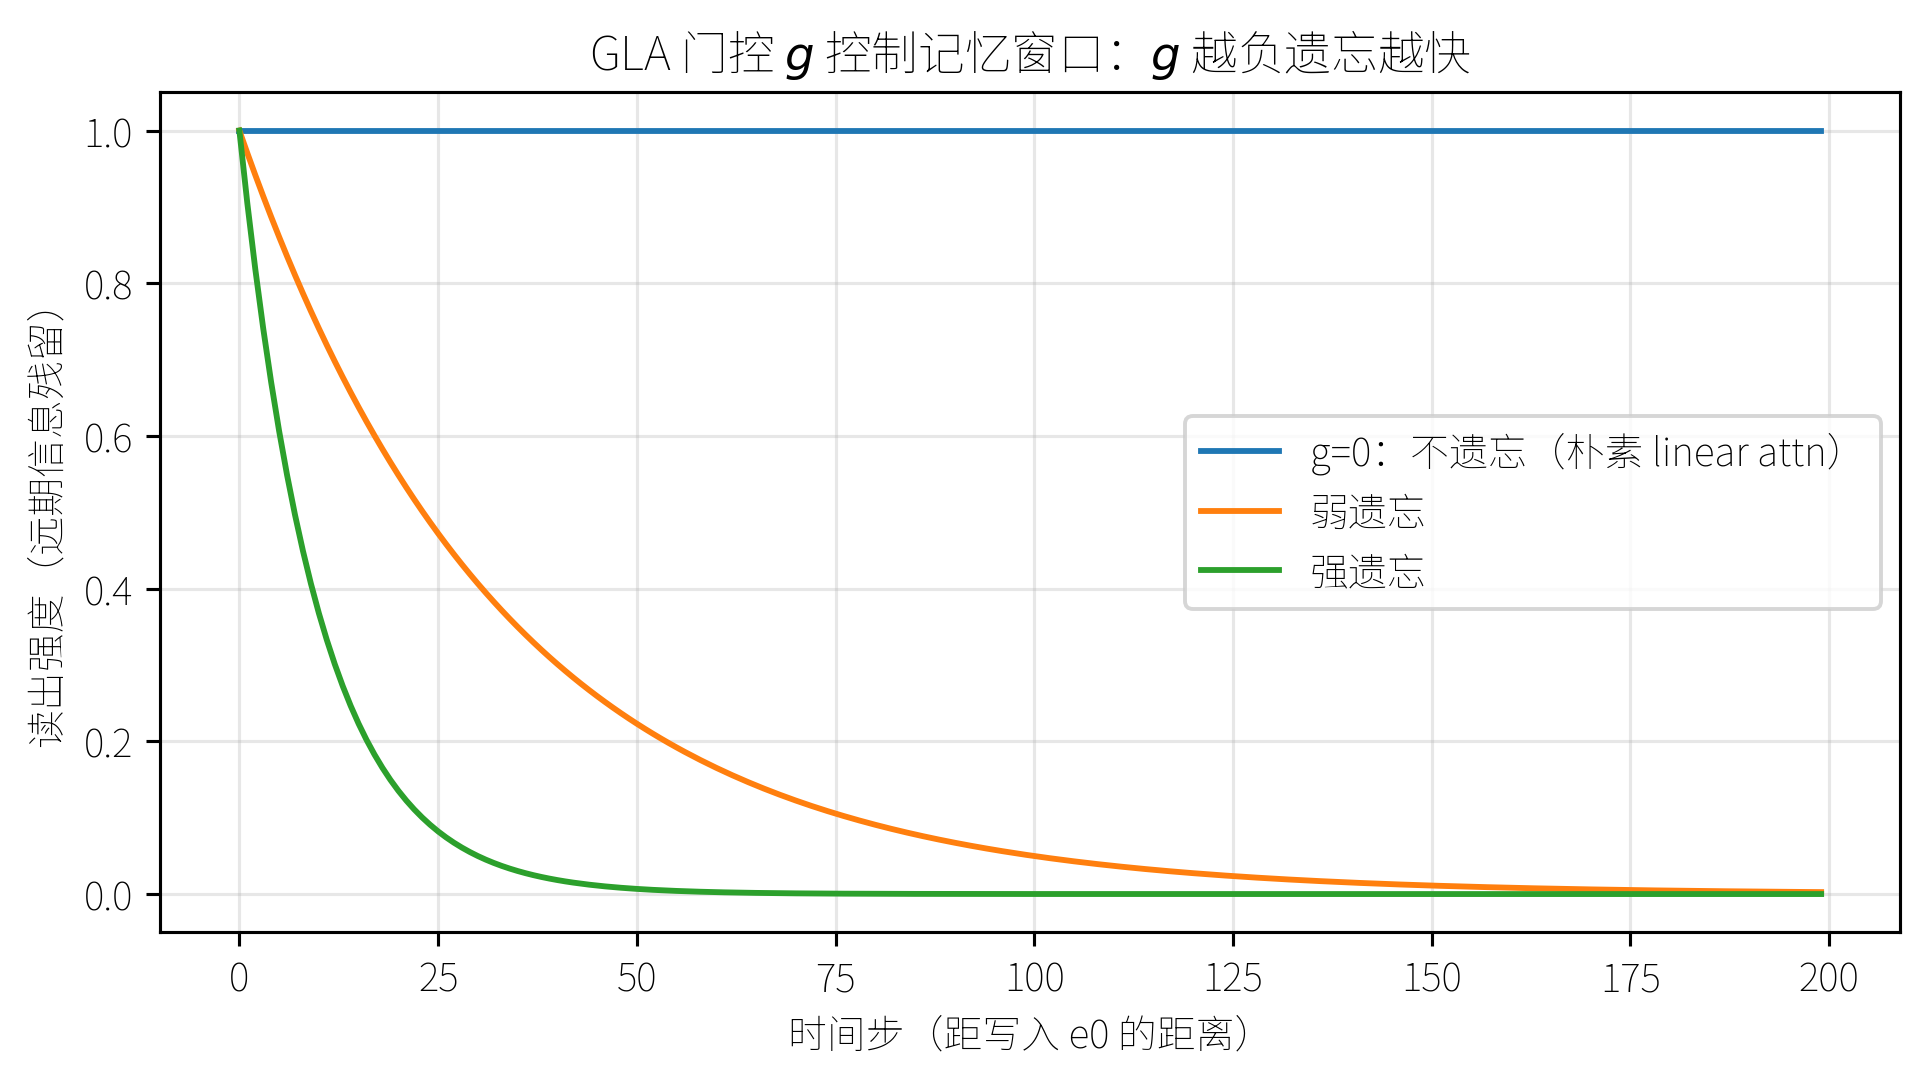

g=0：信息不衰减（朴素 linear attn）；g<0：按通道指数遗忘。data-dependent 的 g 让模型自适应控制记忆长度。


In [4]:
T = 200
def memory_trace(g_val):
    q = torch.zeros(1, 1, T, 16, device="cuda"); k = torch.zeros(1, 1, T, 16, device="cuda")
    v = torch.zeros(1, 1, T, 16, device="cuda")
    k[0, 0, 0, 0] = 1.0; v[0, 0, 0, 0] = 1.0          # t=0 写 (e0 -> e0)
    q[:, :, :, 0] = 1.0                                # 每步都用 e0 query
    g = torch.full((1, 1, T, 16), g_val, device="cuda")
    return gla_recurrent(q, k, v, g, scale=1.0)[0, 0, :, 0].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
for gv, name in [(0.0, "g=0：不遗忘（朴素 linear attn）"), (-0.03, "弱遗忘"), (-0.1, "强遗忘")]:
    plt.plot(memory_trace(gv), label=name)
plt.xlabel("时间步（距写入 e0 的距离）"); plt.ylabel("读出强度（远期信息残留）")
plt.legend(); plt.title("GLA 门控 $g$ 控制记忆窗口：$g$ 越负遗忘越快"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("g=0：信息不衰减（朴素 linear attn）；g<0：按通道指数遗忘。data-dependent 的 g 让模型自适应控制记忆长度。")

## 5. GLA 的 chunk 形式与真实 kernel

GLA 的 chunk 在 §3 的 inter/intra 骨架上，多处理一层**门控衰减**：记块内 $g$ 的前缀和为 $g^{\mathrm{cum}}$，则

- **intra**：块内注意力分数 $\phi(q_i)^\top\phi(k_j)$ 要乘衰减 $e^{g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}$（位置 $i,j$ 间的累积遗忘）；
- **inter**：query 读状态时乘 $e^{g^{\mathrm{cum}}_i}$，状态跨块时乘块末衰减 $e^{g^{\mathrm{cum}}_{\text{last}}}$。

这套"门控 + cumsum"就是 GLA kernel 比朴素 linear attention 多出的部分（无擦除、无 WY 求逆，比 11–13 章简单）。本仓库
**完整拷贝并解耦** GLA 的 3 个 Triton 文件（`_fla_gla_chunk` / `_fla_chunk_h` / `_fla_cumsum` + 薄适配层），靠 **no-op
dispatch** 脱离 fla 独立运行。下面保留**完整源码**——GLA chunk 主体 `_fla_gla_chunk.py`（可滚动），其余文件见
[`SOURCES.md`](./SOURCES.md)。

In [5]:
show_code(str(CH / "_fla_gla_chunk.py"))

### 数值验证：解耦没改任何计算

把本地解耦的 kernel 与 fla 原版逐位对比（定长 + 变长 `cu_seqlens`），再与简要版 recurrent 对齐：

In [6]:
from _fla_gla_chunk import chunk_gla as local
B, T, H, D = 2, 512, 4, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
g = F.logsigmoid(torch.randn(B, T, H, D, device="cuda", dtype=torch.float32, generator=gg))

ol, _ = local(q, k, v, g)
try:
    from fla.ops.gla import chunk_gla as flak
    of, _ = flak(q, k, v, g)
    print(f"① 定长：本地解耦 vs fla 原版   max diff: {(ol.float()-of.float()).abs().max().item():.2e}")
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp, gp = (x.reshape(1, B * T, H, D) for x in (q, k, v, g))
    o2, _ = local(qp, kp, vp, gp, cu_seqlens=cu)
    f2, _ = flak(qp, kp, vp, gp, cu_seqlens=cu)
    print(f"② 变长(cu_seqlens)：本地 vs fla    max diff: {(o2.float()-f2.float()).abs().max().item():.2e}")
except ImportError:
    print("（未装 fla，跳过原版对照）")

o_rec = gla_recurrent(*(x.transpose(1, 2) for x in (q, k, v, g))).transpose(1, 2)
print(f"③ 本地 chunk(bf16) vs 简要版 recurrent(fp32)   max diff: {(ol.float()-o_rec.float()).abs().max().item():.2e}")
print("→ 解耦 kernel 与 fla **bitwise** 一致（见 ①②，max diff=0）。③ 偏差是 bf16 chunk 与 fp32 recurrent 的累积")
print("  精度差：GLA 不做 L2norm（delta 系靠归一化约束状态，GLA 没有），状态动态范围大、bf16 误差偏大，非逻辑差异。")

① 定长：本地解耦 vs fla 原版   max diff: 0.00e+00


② 变长(cu_seqlens)：本地 vs fla    max diff: 0.00e+00
③ 本地 chunk(bf16) vs 简要版 recurrent(fp32)   max diff: 6.25e-02
→ 解耦 kernel 与 fla **bitwise** 一致（见 ①②，max diff=0）。③ 偏差是 bf16 chunk 与 fp32 recurrent 的累积
  精度差：GLA 不做 L2norm（delta 系靠归一化约束状态，GLA 没有），状态动态范围大、bf16 误差偏大，非逻辑差异。


## 6. 变长序列（cu_seqlens）怎么算

前面所有验证都用**定长** batch `[B, T, H, D]`——同一 batch 里每条序列一样长。但真实训练里一个 batch 的序列**长短不一**
（不同文档、不同对话）。把它们装进一个 batch 有两种办法：

- **padding**：补到最长那条的长度 $T_{\max}$，短序列填一堆 pad token。序列长度差异越大，算力浪费在 pad 上越多；
- **packing（变长）**：把 $N$ 条序列在时间维上**首尾拼成一条**（`batch=1`），用 `cu_seqlens` 记录每条的边界。**没有一个 pad
  token**，算力全花在真实 token 上。

线性注意力 / SSM 的 chunk kernel 都**原生支持变长**，靠 `cu_seqlens` 一个参数切换——`chunk_gla` 等 fla kernel 也是各章
`test_*_vs_fla` 里验证变长的方式。

**`cu_seqlens` 格式**：设 $N$ 条序列长度为 $\ell_0,\ell_1,\dots,\ell_{N-1}$，则 `cu_seqlens` 是它们的**前缀和**（含前导 0）：

$$\bigl[\,0,\ \ell_0,\ \ell_0+\ell_1,\ \ldots,\ \textstyle\sum_{i}\ell_i\,\bigr].$$

这是一个 int32、长度 $N{+}1$ 的张量；第 $n$ 条序列恰好占 packed 张量时间维的 `[cu_seqlens[n] : cu_seqlens[n+1]]`。
输入 layout 也从定长的 `[B, T, H, D]` 变成 **`[1, total_len, H, D]`**（batch 维恒为 1，所有序列在第 2 维相接），
门控 $g$ 同为 `[1, total_len, H, D]`。

### chunk kernel 怎么处理变长：块不跨序列 + 状态按序列重置

定长时每条序列各占一个 batch 行、彼此独立、各自从零状态递推。变长把多条序列塞进**同一条** packed 序列后，kernel 必须保证
两件事，否则就会把上一条序列的信息泄漏给下一条：

1. **块（chunk）不能跨序列边界**。定长时直接按 `chunk_size` 均匀切块即可；变长时若一个块横跨两条序列的接缝，§3 的 **intra**
   项（块内因果注意力 $\operatorname{tril}(\phi Q\,\phi K^\top)V$）就会让后一条序列的 token attend 到前一条——错误。所以变长必须
   **每条序列各自**按 `chunk_size` 分块，每条的最后一块允许不满（向上取整）。
2. **状态矩阵 $S$ 在每条序列开头重置为 0**。§3 的 **inter** 项靠块间传递的状态 $S$，但它**不能跨序列 carry**：第 $n$ 条序列的第
   一个块必须从 $S=0$ 起步，绝不能带入第 $n-1$ 条序列末尾的状态。

这就是变长与定长**唯一**的本质区别——逐块的**计算公式一字不改**，只是"哪些块属于哪条序列、状态在哪里清零"要重新安排。这套
映射由两个纯 torch 的索引函数在 kernel 启动前于 host 端算好（`_fla_compat.py`，拷自 fla `ops/utils/index.py`）。

**`prepare_chunk_indices`** —— 把每条序列各自分块，给每个块打上 `(序列号, 序列内第几块)` 标签：

```python
# _fla_compat.py · prepare_chunk_indices（节选，floor-div 即 ceil 分块）
def prepare_chunk_indices(cu_seqlens, chunk_size):
    lens = prepare_lens(cu_seqlens)                       # 各序列长度 = diff(cu_seqlens)
    chunk_counts = (lens + chunk_size - 1) // chunk_size  # 每条序列的块数 = ceil(len / chunk_size)
    seg_id, intra_idx = _segmented_arange(chunk_counts)   # 展开成 (序列号, 序列内块号)
    return torch.stack([seg_id, intra_idx], 1)
```

例：3 条序列长度 `[5, 7, 4]`、`chunk_size=4`，各切 `ceil([5,7,4]/4)=[2,2,1]` 块，共 5 块：

| 全局块号 | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| `(序列号, 序列内块号)` | (0,0) | (0,1) | (1,0) | (1,1) | (2,0) |

kernel 的 grid 按"总块数"（这里 5）启动，每个 block 先读出自己的 `(序列号 i_n, 块号 i_t)`，再用
`bos, eos = cu_seqlens[i_n], cu_seqlens[i_n+1]` 定位这条序列在 packed 张量里的范围——块因此永远落在单条序列内部。

**`prepare_chunk_offsets`** —— 各序列块数的前缀和（上例 `[2,2,1] → [0,2,4,5]`），让"块间状态"的存储缓冲在 packed batch 里
按序列对齐：第 $n$ 条序列的状态块从 `offsets[n]` 开始写。状态递推内核 `_fla_chunk_h.py::chunk_fwd_h` 据此对**每条序列**把累加器
`b_h = tl.zeros([BK, BV])` 重新置零、只在该序列的块范围 `for i_t in range(NT)`（`NT = ceil(本序列长度 / 块大小)`）内循环——
这就在代码层面落实了"状态按序列重置、块不跨序列"。

### 数值验证：packed 一次 == 逐条单独跑

最有力的检验：3 条不等长序列，(a) 拼成 packed + `cu_seqlens` **一次**跑完，(b) 逐条**单独**当定长序列各跑一次再拼回。
若"块不跨序列、状态按序列重置"成立，两者必**逐段一致**（到机器精度）。这次不依赖 fla——直接验证变长的**语义**。

In [7]:
from _fla_gla_chunk import chunk_gla
from _fla_compat import prepare_chunk_indices

H, D = 4, 64
lens = [100, 250, 160]                                  # 3 条不等长序列
total = sum(lens)                                       # packed 后的总长
cu = torch.tensor([0] + torch.tensor(lens).cumsum(0).tolist(),
                  device="cuda", dtype=torch.int32)     # [0, l0, l0+l1, total]
print("cu_seqlens =", cu.tolist(), "  = [0, l0, l0+l1, total]")
ci = prepare_chunk_indices(cu, 64).tolist()             # 每行 (序列号, 序列内块号)
print(f"chunk_indices(chunk_size=64) = {ci}")
print("  3 条序列各切 ceil([100,250,160]/64)=[2,4,3] 块，块号带序列标签、不跨序列\n")

gg = torch.Generator("cuda").manual_seed(7)
# packed layout: [1, total_len, H, D]（batch 维恒为 1，3 条序列在时间维首尾相接）
qp = torch.randn(1, total, H, D, device="cuda", generator=gg)         # float32：packed 与逐条可逐位对齐（证明数学等价）
kp = torch.randn(1, total, H, D, device="cuda", generator=gg)
vp = torch.randn(1, total, H, D, device="cuda", generator=gg)
gp = F.logsigmoid(torch.randn(1, total, H, D, device="cuda", generator=gg))

# (a) packed 一次跑完：传 cu_seqlens，kernel 自动按边界分块、每条序列状态独立
o_packed, _ = chunk_gla(qp, kp, vp, gp, cu_seqlens=cu)

# (b) 逐条单独当定长序列各跑一次（不传 cu_seqlens，各自从零状态开始），再沿时间维拼回
o_each = []
for i in range(len(lens)):
    bos, eos = cu[i].item(), cu[i + 1].item()
    qi, ki, vi, gi = (x[:, bos:eos].contiguous() for x in (qp, kp, vp, gp))
    oi, _ = chunk_gla(qi, ki, vi, gi)
    o_each.append(oi)
o_each = torch.cat(o_each, dim=1)

diff = (o_packed.float() - o_each.float()).abs().max().item()
print(f"packed(cu_seqlens 一次) vs 逐条单独跑   max diff: {diff:.2e}")
print("→ packed 跑出的每条序列 == 单独跑该序列（float32 逐位对齐）：chunk 没跨序列、状态在每条序列开头")
print("  都重置了——这就是变长与定长的唯一区别。（bf16 下因 packed/逐条 shape 不同触发不同 autotune config，")
print("  会有 ~1e-2 量级累积差异，属精度噪声、非逻辑差异。）")

cu_seqlens = [0, 100, 350, 510]   = [0, l0, l0+l1, total]
chunk_indices(chunk_size=64) = [[0, 0], [0, 1], [1, 0], [1, 1], [1, 2], [1, 3], [2, 0], [2, 1], [2, 2]]
  3 条序列各切 ceil([100,250,160]/64)=[2,4,3] 块，块号带序列标签、不跨序列



/home/robomaster/anaconda3/envs/py312_numba/lib/python3.12/site-packages/triton/language/core.py:2284: UserWarning: tl.make_block_ptr is deprecated. Use TensorDescriptor or tl.make_tensor_descriptor instead.
  warn("tl.make_block_ptr is deprecated. Use TensorDescriptor or tl.make_tensor_descriptor instead.")


packed(cu_seqlens 一次) vs 逐条单独跑   max diff: 0.00e+00
→ packed 跑出的每条序列 == 单独跑该序列（float32 逐位对齐）：chunk 没跨序列、状态在每条序列开头
  都重置了——这就是变长与定长的唯一区别。（bf16 下因 packed/逐条 shape 不同触发不同 autotune config，
  会有 ~1e-2 量级累积差异，属精度噪声、非逻辑差异。）


## 7. 复杂度：$O(S)$ vs full attention $O(S^2)$

GLA 是线性复杂度，长序列优于 full attention；门控带来选择性记忆，质量优于无门控的朴素 linear attention。

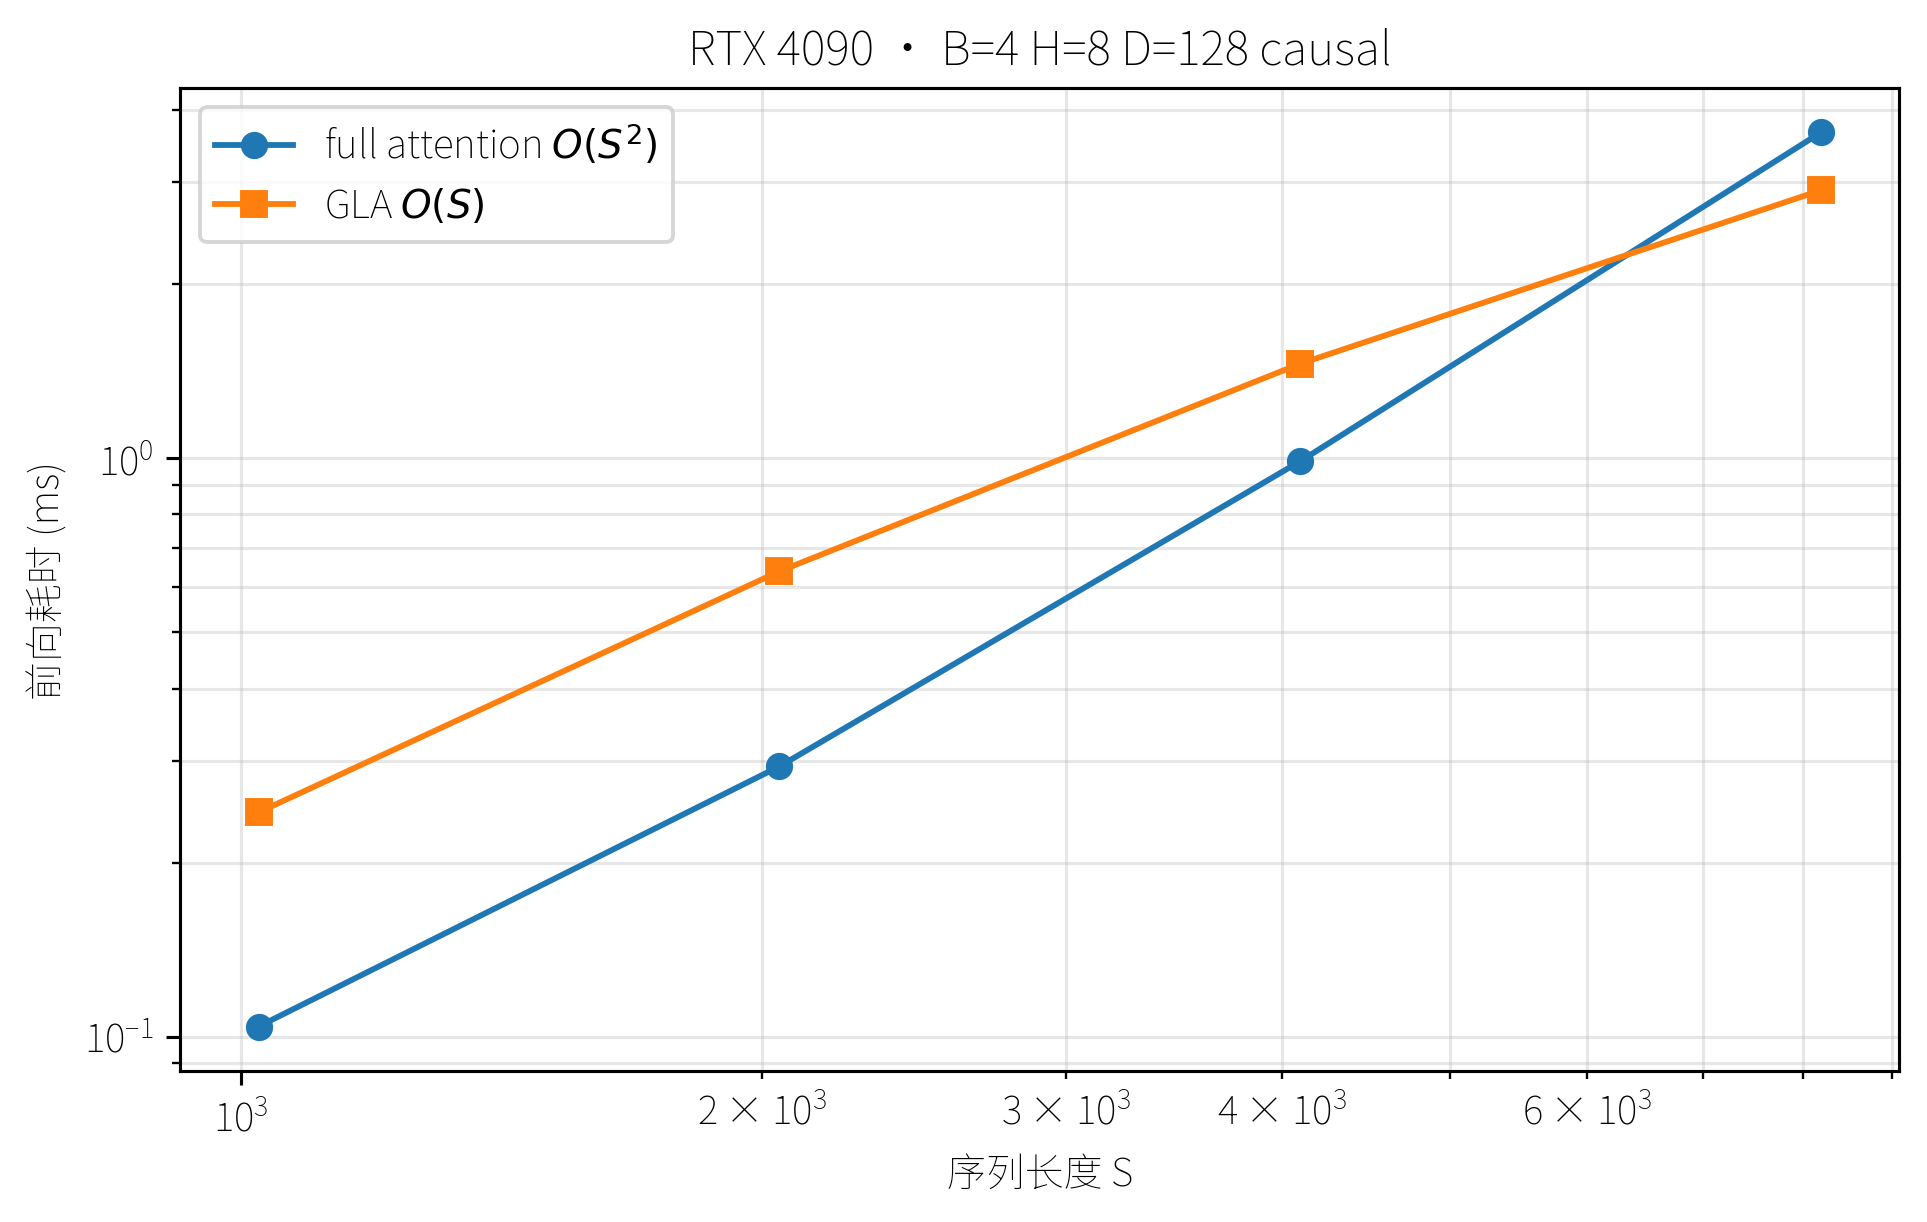

S= 1024  full  0.104ms  GLA  0.244ms (0.43×)
S= 2048  full  0.293ms  GLA  0.638ms (0.46×)
S= 4096  full  0.988ms  GLA  1.457ms (0.68×)
S= 8192  full  3.657ms  GLA  2.905ms (1.26×)


In [8]:
from common import bench_ms
from gla_triton import gla_chunk

B, H, D = 4, 8, 128
Ss = [1024, 2048, 4096, 8192]
full, gla_t = [], []
for S in Ss:
    q = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    qb, kb, vb = (x.to(torch.bfloat16) for x in (q, k, v))
    g = F.logsigmoid(torch.randn(B, H, S, D, device="cuda", dtype=torch.float32))
    full.append(bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True)))
    gla_t.append(bench_ms(lambda: gla_chunk(qb, kb, vb, g)))

plt.figure(figsize=(7, 4.5))
plt.plot(Ss, full, "o-", label="full attention $O(S^2)$")
plt.plot(Ss, gla_t, "s-", label="GLA $O(S)$")
plt.xlabel("序列长度 S"); plt.ylabel("前向耗时 (ms)"); plt.yscale("log"); plt.xscale("log")
plt.title("RTX 4090 · B=4 H=8 D=128 causal"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for i, S in enumerate(Ss):
    print(f"S={S:>5}  full {full[i]:6.3f}ms  GLA {gla_t[i]:6.3f}ms ({full[i]/gla_t[i]:.2f}×)")

## 🛠 动手练习

1. **退化验证**：把 GLA 的门控 `g` 全设 0，验证它精确退化为无门控的 linear attention（`linear_attn_recurrent`）。
2. **三形式的取舍**：parallel / recurrent / chunked 在 `S=8192` 时哪个显存最省？为什么 causal 下 parallel 仍是 $O(S^2)$？
   （提示：causal mask 需要显式的 $S\times S$ 分数矩阵。）
3. **chunk_size 的影响**：把 `chunk_size` 改成 16 / 64 / 256，看 `chunk ≡ recurrent` 的误差和速度怎么变——块越大并行度越高，
   但块内 $O(C^2)$ 部分越重。

## 8. 收尾

线性注意力把 $O(S^2)$ 的注意力变成了一个固定大小**状态矩阵**的 $O(S)$ 递推：

1. **矩阵结合律**（§1）：$\phi(Q)\bigl(\phi(K)^\top V\bigr)$ 把 $S\times S$ 分数矩阵换成 $K\times V$ 状态矩阵；
2. **三种等价形式**（§2–§3）：parallel（概念）/ recurrent（ground truth）/ chunked（块内并行 + 块间传状态，kernel 骨架）；
3. **GLA 门控**（§4–§5）：$\operatorname{diag}(e^{g_t})$ 让状态 data-dependent 地选择性遗忘，是后续 KDA/GDN 门控的来源；
4. **完整 kernel**（§5）：本仓库完整解耦自 fla、与原版数值一致；
5. **变长序列**（§6）：packing + `cu_seqlens` 把多条不等长序列拼成一条免 padding，chunk kernel 靠"块不跨序列 + 状态按序列重置"保证正确——这是 chunked 形式天然支持、softmax attention 也共用的训练高效技巧。

GLA 的写入仍是"只加"——**下一章** → 11-deltanet 引入 delta rule 的"先擦后写"，给状态装上橡皮擦；再到 12 KDA 把门控与
擦除合一、13 GDN 把擦/写解耦。这条线就是围绕"状态矩阵怎么更新"一步步加机制。